# Import liberaries

In [0]:
!pip install category_encoders
!pip install xgboost
!pip install shap 

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
import numpy as np

# preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce


# piplines
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder


# scoring 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap


# models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# visualization
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# ML flow 
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# Data Load

In [0]:
df = spark.table("brazilian_e_commerce.gold.obt_ml").toPandas()

#  Quick exploration, because it was all done in ELT pipeline

In [0]:
display(df.head(5))
print(df.shape)

order_id,total_items,total_price,total_freight_value,main_product_category,main_seller_zip,main_seller_city,main_seller_state,avg_product_name_lenght,avg_product_description_lenght,avg_product_weight_g,avg_product_length_cm,avg_product_height_cm,avg_product_width_cm,purchause_to_delivery_days,purchase_hour,purchase_day_of_week,purchase_month,purchase_year,customer_zip_code_prefix,customer_city,customer_state,max_payment_value,avg_payment_value,main_payment_type,total_payments
74c951ce0835b2741d3014321ae9c480,1,129.89999389648438,9.65999984741211,cool_stuff,13324,salto,SP,51.0,1141.0,393.0,17.0,7.0,14.0,2,17,2,8,2018,6086,osasco,SP,139.56,139.55999755859375,credit_card,1
4709741e829775567b92abc42437b461,1,94.5,23.239999771118164,bed_bath_table,88359,brusque,SC,37.0,1049.0,2150.0,26.0,26.0,23.0,11,22,5,3,2018,11706,praia grande,SP,117.74,117.73999786376953,credit_card,1
65176291fad85f25b92153f7172abbc5,1,52.0,9.4399995803833,home_appliances,11704,praia grande,SP,53.0,472.0,125.0,23.0,8.0,13.0,2,8,4,4,2018,13275,valinhos,SP,61.44,61.439998626708984,credit_card,1
e16efc3cc50ac44b70f993463b609174,1,89.9000015258789,12.130000114440918,bed_bath_table,14940,ibitinga,SP,54.0,245.0,1383.0,50.0,10.0,40.0,11,13,1,7,2017,13141,paulinia,SP,102.03,102.02999877929688,credit_card,1
8551e4893fc1357dda960b1a7202b53d,1,103.12000274658203,11.350000381469727,garden_tools,13087,campinas,SP,52.0,347.0,850.0,22.0,5.0,45.0,5,6,5,6,2018,13187,hortolandia,SP,114.47,114.47000122070312,credit_card,1


(96454, 26)


In [0]:
df.isnull().sum()

order_id                           0
total_items                        0
total_price                        0
total_freight_value                0
main_product_category              0
main_seller_zip                    0
main_seller_city                   0
main_seller_state                  0
avg_product_name_lenght            0
avg_product_description_lenght     0
avg_product_weight_g              16
avg_product_length_cm             16
avg_product_height_cm             16
avg_product_width_cm              16
purchause_to_delivery_days         0
purchase_hour                      0
purchase_day_of_week               0
purchase_month                     0
purchase_year                      0
customer_zip_code_prefix           0
customer_city                      0
customer_state                     0
max_payment_value                  0
avg_payment_value                  0
main_payment_type                  0
total_payments                     0
dtype: int64

In [0]:
df.describe()[['purchause_to_delivery_days']]

,purchause_to_delivery_days
count,96454.000000
mean,12.495863
std,9.553979
min,0.000000
25%,7.000000
50%,10.000000
75%,16.000000
max,210.000000


## Data split 

We delate order_id becouse its not relevant and reviews count becouse its a data leackage using it 

In [0]:
X = df.drop(['order_id','purchause_to_delivery_days'], axis=1)
y = df['purchause_to_delivery_days']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [0]:
X_train.head(5)

,total_items,total_price,total_freight_value,main_product_category,main_seller_zip,main_seller_city,main_seller_state,avg_product_name_lenght,avg_product_description_lenght,avg_product_weight_g,avg_product_length_cm,avg_product_height_cm,avg_product_width_cm,purchase_hour,purchase_day_of_week,purchase_month,purchase_year,customer_zip_code_prefix,customer_city,customer_state,max_payment_value,avg_payment_value,main_payment_type,total_payments
64475,1,59.900002,17.260000,stationery,35557,carmo do cajuru,MG,56.0,1349.0,1100.0,27.0,10.0,20.0,17,5,4,2017,86300,cornelio procopio,PR,77.160004,77.160004,credit_card,1
71710,1,12.880000,11.850000,computers_accessories,11010,santos,SP,51.0,448.0,180.0,16.0,9.0,16.0,19,7,9,2017,19360,santo anastacio,SP,24.730000,24.730000,credit_card,1
55675,1,81.900002,22.629999,health_beauty,2066,sao paulo,SP,47.0,225.0,1350.0,26.0,18.0,11.0,1,7,3,2018,66083,belem,PA,104.529999,104.529999,credit_card,1
58210,1,41.900002,7.550000,sports_leisure,7859,franco da rocha,SP,53.0,689.0,217.0,18.0,13.0,15.0,9,3,8,2018,7020,guarulhos,SP,49.450001,49.450001,credit_card,1
42709,2,179.919998,78.519997,office_furniture,8577,itaquaquecetuba,SP,19.0,883.0,10075.0,55.0,64.0,26.0,19,5,3,2017,47850,luis eduardo magalhaes,BA,258.440002,258.440002,boleto,1


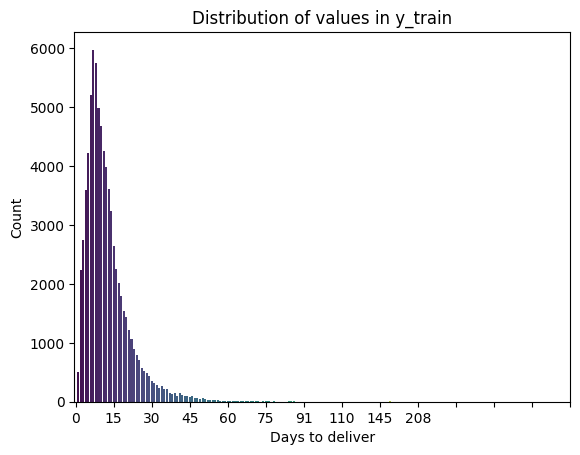

0 - 210


In [0]:
sns.countplot(x=y_train, palette="viridis")
plt.xticks(range(y_train.min(), y_train.max(), 15))
plt.title("Distribution of values in y_train")
plt.xlabel("Days to deliver")
plt.ylabel("Count")
plt.show()

print(y_train.min(),"-", y_train.max())

In [0]:
X_train.head(5)

,total_items,total_price,total_freight_value,main_product_category,main_seller_zip,main_seller_city,main_seller_state,avg_product_name_lenght,avg_product_description_lenght,avg_product_weight_g,avg_product_length_cm,avg_product_height_cm,avg_product_width_cm,purchase_hour,purchase_day_of_week,purchase_month,purchase_year,customer_zip_code_prefix,customer_city,customer_state,max_payment_value,avg_payment_value,main_payment_type,total_payments
64475,1,59.900002,17.260000,stationery,35557,carmo do cajuru,MG,56.0,1349.0,1100.0,27.0,10.0,20.0,17,5,4,2017,86300,cornelio procopio,PR,77.160004,77.160004,credit_card,1
71710,1,12.880000,11.850000,computers_accessories,11010,santos,SP,51.0,448.0,180.0,16.0,9.0,16.0,19,7,9,2017,19360,santo anastacio,SP,24.730000,24.730000,credit_card,1
55675,1,81.900002,22.629999,health_beauty,2066,sao paulo,SP,47.0,225.0,1350.0,26.0,18.0,11.0,1,7,3,2018,66083,belem,PA,104.529999,104.529999,credit_card,1
58210,1,41.900002,7.550000,sports_leisure,7859,franco da rocha,SP,53.0,689.0,217.0,18.0,13.0,15.0,9,3,8,2018,7020,guarulhos,SP,49.450001,49.450001,credit_card,1
42709,2,179.919998,78.519997,office_furniture,8577,itaquaquecetuba,SP,19.0,883.0,10075.0,55.0,64.0,26.0,19,5,3,2017,47850,luis eduardo magalhaes,BA,258.440002,258.440002,boleto,1


## Explain correlation between features

In [0]:

col_names = ['main_product_category','main_seller_city','main_seller_state','customer_city','customer_state','main_payment_type']

le = LabelEncoder()

for i in col_names:
    encoded = le.fit_transform(X_train[i])
    print(f"{i} - {encoded.max()}")

main_product_category - 71
main_seller_city - 578
main_seller_state - 21
customer_city - 3812
customer_state - 26
main_payment_type - 3


In [0]:
ohe = OneHotEncoder(sparse_output=False, drop='first')

encoded = ohe.fit_transform(X_train[['main_payment_type']])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['main_payment_type']), index=X_train.index)

X_train_ohe = X_train.drop(columns=['main_payment_type']).join(encoded_df)


In [0]:
col_names = ['main_product_category','main_seller_city','main_seller_state','customer_city','customer_state']

te = ce.TargetEncoder(cols=col_names)
X_encoded = te.fit_transform(X_train_ohe, y_train)
X_encoded = pd.concat([X_encoded, y_train], axis=1)
X_encoded.head(5)


,total_items,total_price,total_freight_value,main_product_category,main_seller_zip,main_seller_city,main_seller_state,avg_product_name_lenght,avg_product_description_lenght,avg_product_weight_g,avg_product_length_cm,avg_product_height_cm,avg_product_width_cm,purchase_hour,purchase_day_of_week,purchase_month,purchase_year,customer_zip_code_prefix,customer_city,customer_state,max_payment_value,avg_payment_value,total_payments,main_payment_type_credit_card,main_payment_type_debit_card,main_payment_type_voucher,purchause_to_delivery_days
64475,1,59.900002,17.260000,12.811837,35557,13.394696,12.939835,56.0,1349.0,1100.0,27.0,10.0,20.0,17,5,4,2017,86300,12.607746,11.941549,77.160004,77.160004,1,1.0,0.0,0.0,15
71710,1,12.880000,11.850000,13.090839,11010,11.116456,12.271312,51.0,448.0,180.0,16.0,9.0,16.0,19,7,9,2017,19360,11.942210,8.710532,24.730000,24.730000,1,1.0,0.0,0.0,10
55675,1,81.900002,22.629999,12.042612,2066,11.236619,12.271312,47.0,225.0,1350.0,26.0,18.0,11.0,1,7,3,2018,66083,22.194366,23.913793,104.529999,104.529999,1,1.0,0.0,0.0,42
58210,1,41.900002,7.550000,12.129113,7859,10.711635,12.271312,53.0,689.0,217.0,18.0,13.0,15.0,9,3,8,2018,7020,8.006403,8.710532,49.450001,49.450001,1,1.0,0.0,0.0,1
42709,2,179.919998,78.519997,20.770230,8577,21.711656,12.271312,19.0,883.0,10075.0,55.0,64.0,26.0,19,5,3,2017,47850,19.128553,19.366705,258.440002,258.440002,1,0.0,0.0,0.0,20


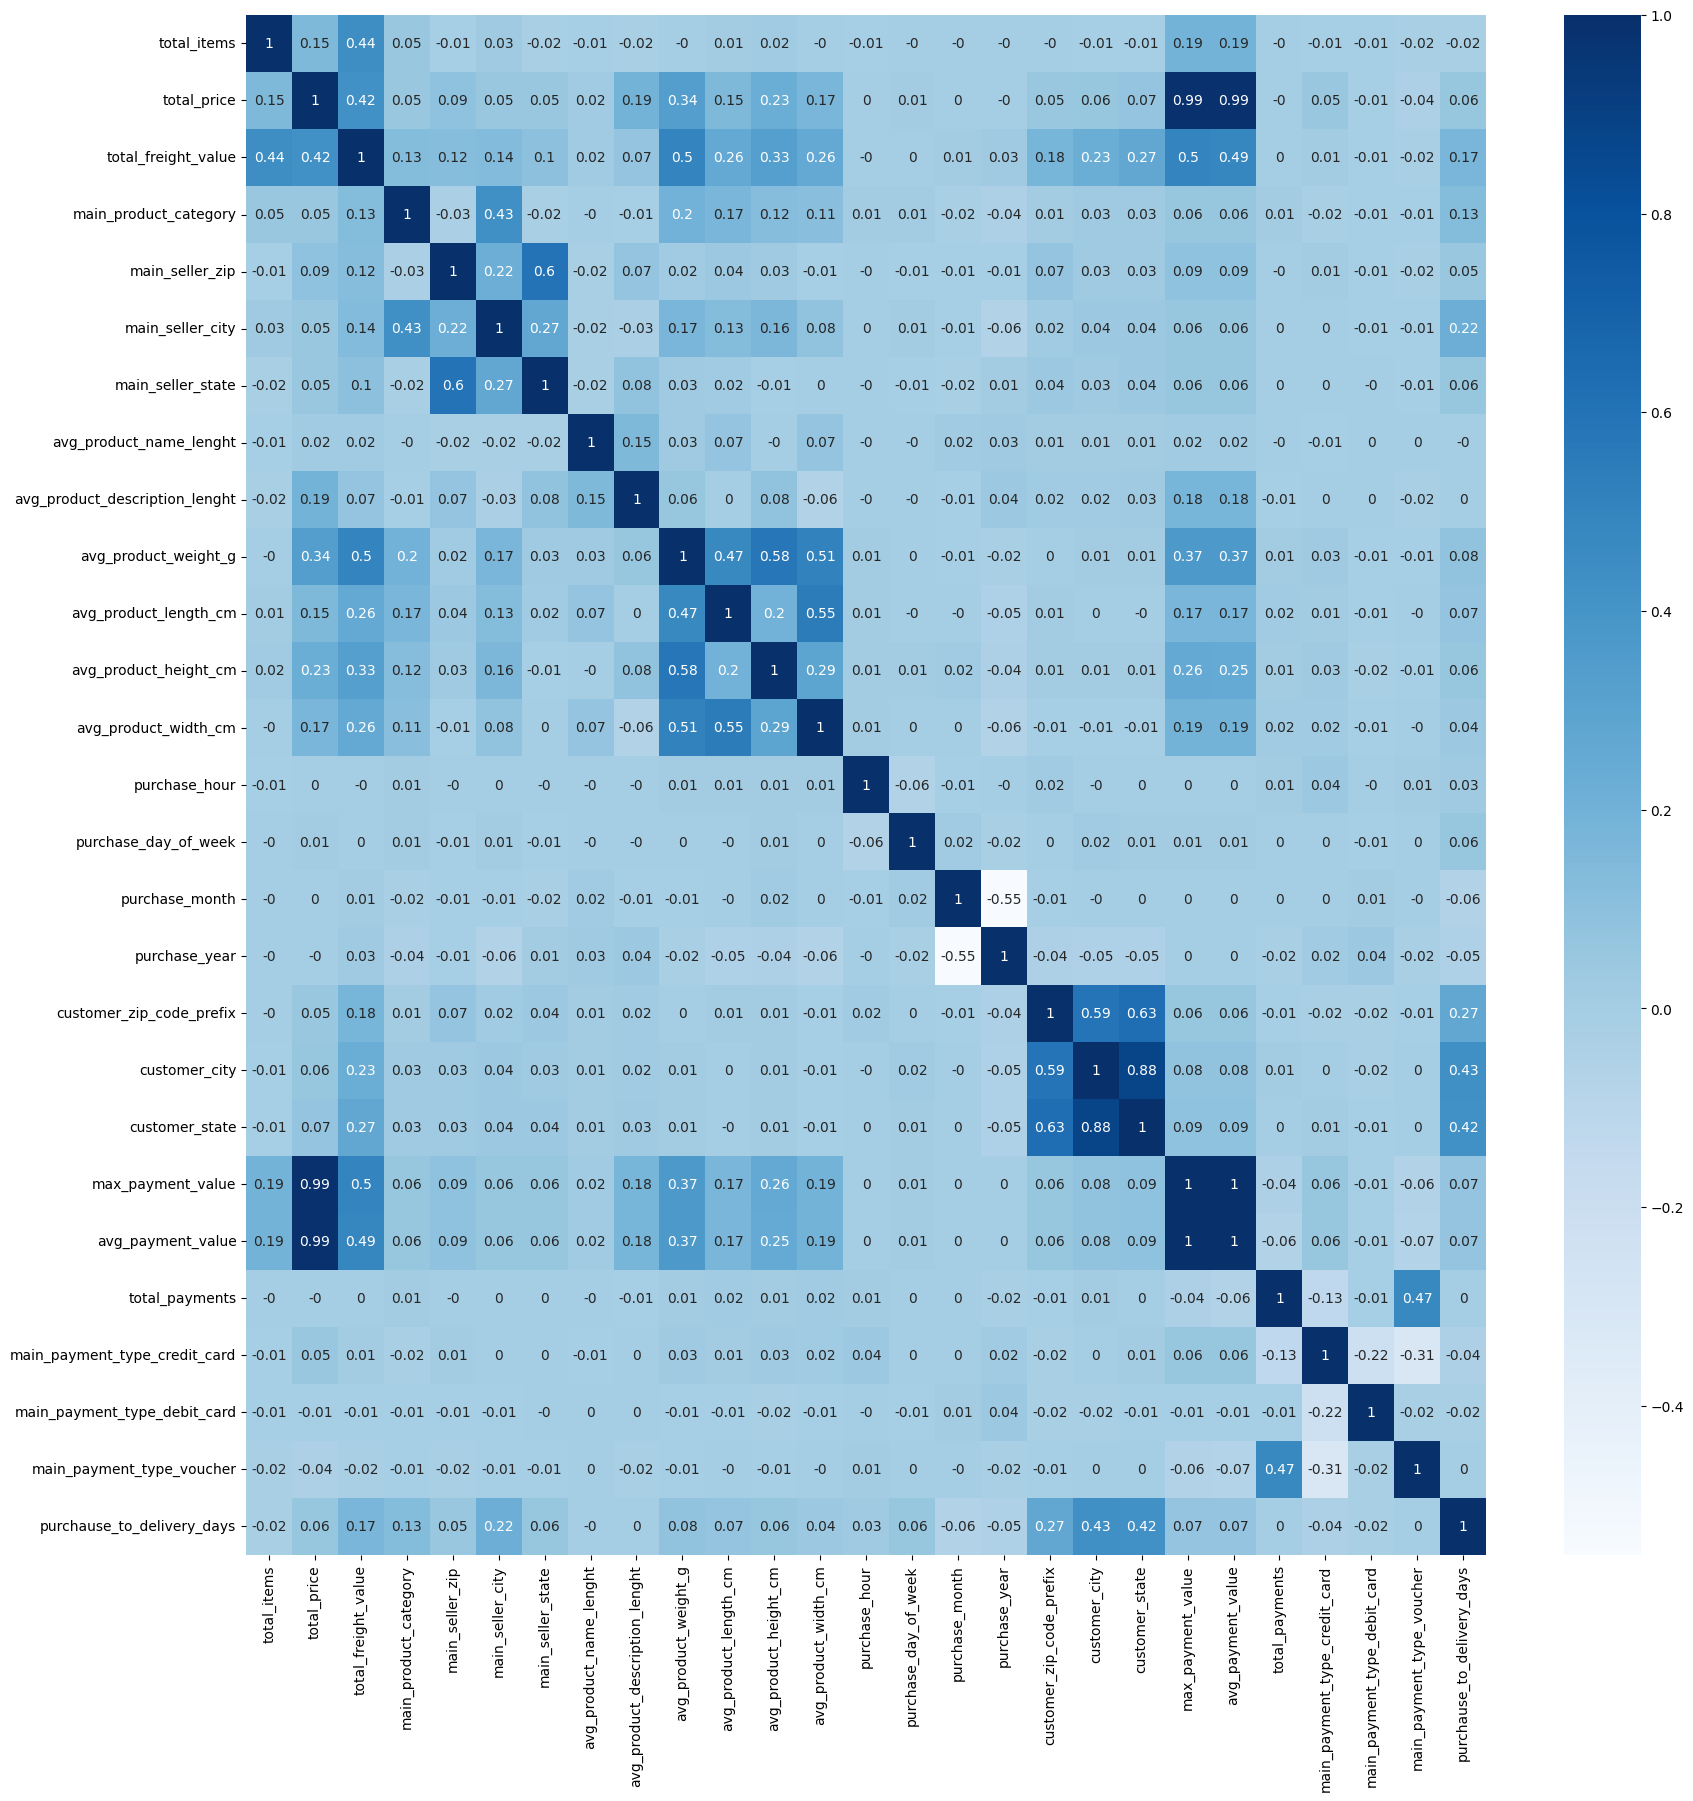

In [0]:
# corr plot
corr = X_encoded.corr()
corr = corr.round(2)
plt.figure(figsize=(20,20))
sns.heatmap(corr, cmap='Blues', annot=True)
plt.show()

In [0]:
# # We can drop some of the columns with low correlation with the target
# # And columns that are high corelated with other columns 
# columns = ['total_items','avg_product_name_lenght','avg_product_description_lenght','purhase_hour','total_payments','main_payment_type']
# X_train.drop(columns=columns, inplace=True)
# X_test.drop(columns=columns, inplace=True)

# Preprocessing

## Creating Pipeline 

### num Pipeline

In [0]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

### Categorical Pipeline


In [0]:
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='none_data')),
    ('targetencoder', TargetEncoder(smoothing=1.0, min_samples_leaf=1))
])

In [0]:
ohe_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='none_data')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

### Combining Piplines

In [0]:
X_train.head(5)

,total_items,total_price,total_freight_value,main_product_category,main_seller_zip,main_seller_city,main_seller_state,avg_product_name_lenght,avg_product_description_lenght,avg_product_weight_g,avg_product_length_cm,avg_product_height_cm,avg_product_width_cm,purchase_hour,purchase_day_of_week,purchase_month,purchase_year,customer_zip_code_prefix,customer_city,customer_state,max_payment_value,avg_payment_value,main_payment_type,total_payments
64475,1,59.900002,17.260000,stationery,35557,carmo do cajuru,MG,56.0,1349.0,1100.0,27.0,10.0,20.0,17,5,4,2017,86300,cornelio procopio,PR,77.160004,77.160004,credit_card,1
71710,1,12.880000,11.850000,computers_accessories,11010,santos,SP,51.0,448.0,180.0,16.0,9.0,16.0,19,7,9,2017,19360,santo anastacio,SP,24.730000,24.730000,credit_card,1
55675,1,81.900002,22.629999,health_beauty,2066,sao paulo,SP,47.0,225.0,1350.0,26.0,18.0,11.0,1,7,3,2018,66083,belem,PA,104.529999,104.529999,credit_card,1
58210,1,41.900002,7.550000,sports_leisure,7859,franco da rocha,SP,53.0,689.0,217.0,18.0,13.0,15.0,9,3,8,2018,7020,guarulhos,SP,49.450001,49.450001,credit_card,1
42709,2,179.919998,78.519997,office_furniture,8577,itaquaquecetuba,SP,19.0,883.0,10075.0,55.0,64.0,26.0,19,5,3,2017,47850,luis eduardo magalhaes,BA,258.440002,258.440002,boleto,1


In [0]:
print(f"{X_train.shape[1]} - Total columns")

num_columns = X_train.select_dtypes(include=['float64','float32','int64','int32']).columns
print(f"{len(num_columns)} - Num columns")

ohe_columns = ['main_payment_type']
print(f"{len(ohe_columns)} - ohe columns")

cat_columns = X_train.select_dtypes(include=['object']).columns.drop(ohe_columns)
print(f"{len(cat_columns)} - Categorical columns")


print(f"{len(num_columns) + len(cat_columns) + len(ohe_columns)} - SUM")

24 - Total columns
16 - Num columns
1 - ohe columns
7 - Categorical columns
24 - SUM


In [0]:
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', ohe_transformer, ohe_columns),
        ('cat', cat_transformer, cat_columns),
        ('num', num_transformer, num_columns)
    ]
    , remainder='drop'
)

### Connect pipelines

In [0]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('model', LinearRegression()) 
])

# Learning proces

### Its a regression problem, so we will use reggresion models: 
- base line will be linear Regressor - easy to interprate 
- Random Forest Regressor
- benchmark model will be XGBoost Regressor - propably the best accuracy 

In [0]:
def show_scores(cv_results):
    df = pd.DataFrame(cv_results)
    
    df['model'] = df['param_model'].apply(lambda x: x.__class__.__name__)
    
    params_expanded = df['params'].apply(pd.Series)
    params_expanded = params_expanded.drop(columns=['model'])

    result = pd.concat([
        df[['model', 'mean_test_score', 'std_test_score', 'rank_test_score']],
        params_expanded
    ], axis=1)  

    result = result.sort_values('rank_test_score').reset_index(drop=True)
    
    display(result)

## Random Search

We can skip this step, its better for serching the best parameters. And if we know them its better to use Grid or direct train them 

In [0]:
# from scipy.stats import randint, uniform

# param_distributions = [
#     {
#         'model': [RandomForestRegressor(random_state=42, n_jobs=1)], 
#         'model__n_estimators': [100],     
#         'model__max_depth': [10],         
#         'model__min_samples_split': [5]    
#     },
#     {
#         'model': [XGBRegressor(
#             random_state=42, 
#             objective='reg:absoluteerror',
#             n_jobs=1,
#             tree_method='hist'
#         )],
#         'model__n_estimators': randint(140, 280),        
#         'model__max_depth': [6, 7, 8],                     
#         'model__learning_rate': uniform(0.115, 0.020),     
#         'model__subsample': [0.85, 0.9],                   
#         'model__colsample_bytree': uniform(0.74, 0.20),    
#         'model__min_child_weight': [2, 3, 4],              
#         'model__reg_alpha': uniform(0, 0.3),               
#         'model__reg_lambda': uniform(0.8, 0.5)             
#     }
# ]

In [0]:
# # ML flow loggs 
# mlflow.sklearn.autolog(
#     log_input_examples=True, 
#     log_model_signatures=True,
#     log_models=True,
#     disable=False,
#     exclusive=False,
#     max_tuning_runs=5  # saves best 5 runs
# )

In [0]:
# random_search = RandomizedSearchCV(
#     estimator=pipeline,
#     param_distributions=param_distributions, 
#     n_iter=20,                          
#     cv=3,                               
#     scoring='neg_mean_absolute_error', 
#     n_jobs=-1,
#     random_state=42,
#     verbose=2                          
# )

# random_search.fit(X_train, y_train)

In [0]:
# show_scores(random_search.cv_results_)

## Grid Search 

In [0]:
param_grid = [
    {
        'model': [RandomForestRegressor(random_state=42, n_jobs=1)], 
        'model__n_estimators': [100],     
        'model__max_depth': [10],         
        'model__min_samples_split': [5]    
    },
    {
        'model': [XGBRegressor(
            random_state=42, 
            objective='reg:absoluteerror',
            n_jobs=1,
            tree_method='hist',
            # Previous best params to make it faster
            subsample=0.9,
            colsample_bytree=0.78,
            min_child_weight=3,
            reg_alpha=0.15,
            reg_lambda=1.20
        )],
        'model__n_estimators': [190, 220],          
        'model__max_depth': [7, 8],                 
        'model__learning_rate': [0.120, 0.125]      
    }
]

In [0]:
mlflow.sklearn.autolog(
    log_input_examples=True, 
    log_model_signatures=True,
    log_models=True,
    disable=False,
    exclusive=False,
    max_tuning_runs=5  # saves best 5 runs
)

In [0]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,            
    cv=3,                               
    scoring='neg_mean_absolute_error', 
    n_jobs=-1,
    verbose=2                           
)
grid_search.fit(X_train, y_train)

2026/04/27 13:55:29 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '91f541dc6b5544b9a67045118bf97fad', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV] END model=RandomForestRegressor(n_jobs=1, random_state=42), model__max_depth=10, model__min_samples_split=5, model__n_estimators=100; total time=  37.8s
[CV] END model=XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.78, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=1, num_parallel_tree=None, ...), model__learning_rate=0

🔗 View Logged Model at: https://dbc-b6718270-b8cf.cloud.databricks.com/ml/experiments/632949943363976/models/m-222db5d56e974d67a1fdec8d6bf8d254?o=7474655816300329
🔗 View Logged Model at: https://dbc-b6718270-b8cf.cloud.databricks.com/ml/experiments/632949943363976/models/m-be54d399999343a38b158687f23c25f9?o=7474655816300329
2026/04/27 13:57:35 INFO mlflow.sklearn.utils: Logging the 5 best runs, 4 runs will be omitted.


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('ohe',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(fill_value='none_data',
                                                                                                        strategy='constant')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['main_payment_type']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(fill_valu...
                                                 max_cat_threshold=None,
                                                 max_cat_to_onehot=None,
                                                 max_delta_step=None,
                                                 max_depth=None,
                                                 max_leaves=None,
                                                 min_child_weight=3,
                                                 missing=nan,
                                                 monotone_constraints=None,
                                                 multi_strategy=None,
                                                 n_estimators=None, n_jobs=1,
                                                 num_parallel_tree=None, ...)],
                          'model__learning_rate': [0.12, 0.125],
                          'model__max_depth': [7, 8],
                          'model__n_estimators': [190, 220]}],
             scoring='neg_mean_absolute_error', verbose=2)

In [0]:
show_scores(grid_search.cv_results_)

model,mean_test_score,std_test_score,rank_test_score,model__max_depth,model__min_samples_split,model__n_estimators,model__learning_rate
XGBRegressor,-4.800610224405925,0.018722043792418343,1,7,null,220,0.125
XGBRegressor,-4.8017354011535645,0.01743861655545021,2,7,null,190,0.125
XGBRegressor,-4.802275975545247,0.020897959939938125,3,7,null,220,0.12
XGBRegressor,-4.803658485412598,0.020889781592719595,4,7,null,190,0.12
XGBRegressor,-4.8056338628133135,0.022209554666127004,5,8,null,190,0.12
XGBRegressor,-4.806197166442871,0.021557377555217284,6,8,null,220,0.12
XGBRegressor,-4.807054201761882,0.020599558975540957,7,8,null,190,0.125
XGBRegressor,-4.807933648427327,0.019657196269678216,8,8,null,220,0.125
RandomForestRegressor,-5.261413533770898,0.012258164865488695,9,10,5.0,100,null


# Evaluation

2026/04/27 13:57:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-b6718270-b8cf.cloud.databricks.com/ml/experiments/632949943363976/models/m-b4de3b9a959d407f9f7edfae1c3ee422?o=7474655816300329


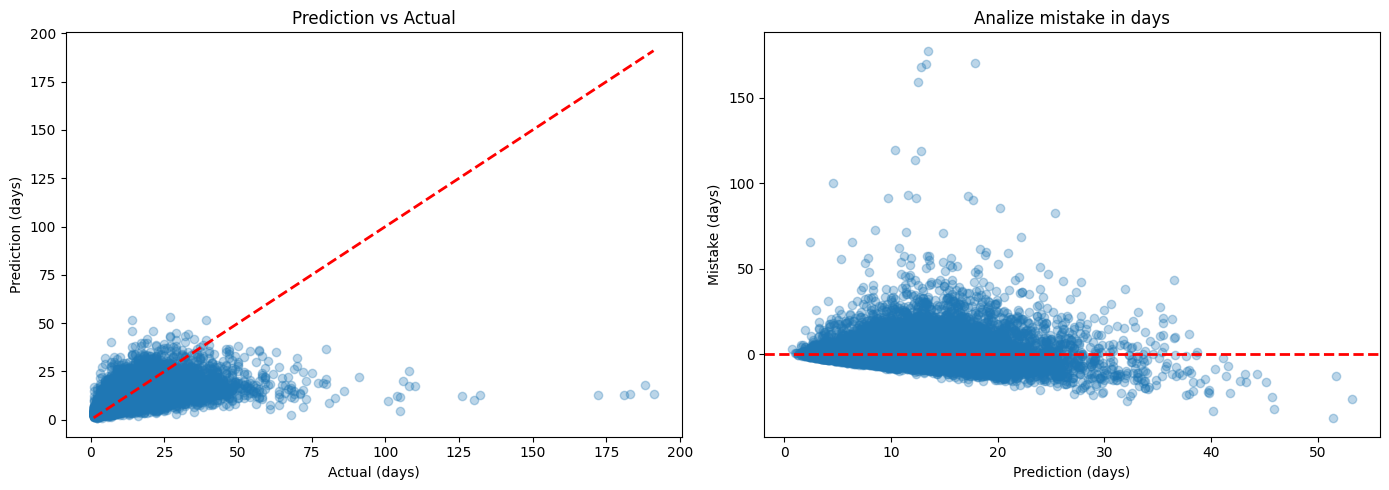

Evaluation on test data
MAE:  4.630 days
RMSE: 8.114 days
MSE:  65.830
R²:   0.2824

 Model saved to MLflow
Run ID: 23583c05462b4e1bb9e6a1858da33c12


In [0]:
# best model 
best_model = grid_search.best_estimator_

# predict the best model on test data
y_pred = best_model.predict(X_test)

# metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

with mlflow.start_run(run_name="Best_Model_Test_Evaluation"):
    
    # log best params
    mlflow.log_params(grid_search.best_params_)
    
    # log test metrixs
    mlflow.log_metric("test_mae", mae)
    mlflow.log_metric("test_rmse", rmse)
    mlflow.log_metric("test_mse", mse)
    mlflow.log_metric("test_r2", r2)
    
    # Log training scores 
    mlflow.log_metric("cv_mae", -grid_search.best_score_)
    
    # Log the best model 
    mlflow.sklearn.log_model(
        best_model, 
        "best_model",
        input_example=X_train.iloc[:5] 
    )
    
    # Log plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    residuals = y_test - y_pred
    
    # Prediction vs Actual
    axes[0].scatter(y_test, y_pred, alpha=0.3)
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0].set_xlabel('Actual (days)')
    axes[0].set_ylabel('Prediction (days)')
    axes[0].set_title('Prediction vs Actual')
    
    # Residuals
    axes[1].scatter(y_pred, residuals, alpha=0.3)
    axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[1].set_xlabel('Prediction (days)')
    axes[1].set_ylabel('Mistake (days)')
    axes[1].set_title('Analize mistake in days')
    
    plt.tight_layout()
    
    # Save the plot 
    mlflow.log_figure(fig, "test_predictions_and_residuals.png")
    plt.show()
    
    print("="*50)
    print("Evaluation on test data")
    print("="*50)
    print(f"MAE:  {mae:.3f} days")
    print(f"RMSE: {rmse:.3f} days")
    print(f"MSE:  {mse:.3f}")
    print(f"R²:   {r2:.4f}")
    print("="*50)
    print(f"\n Model saved to MLflow")
    print(f"Run ID: {mlflow.active_run().info.run_id}")

## Feature Importances

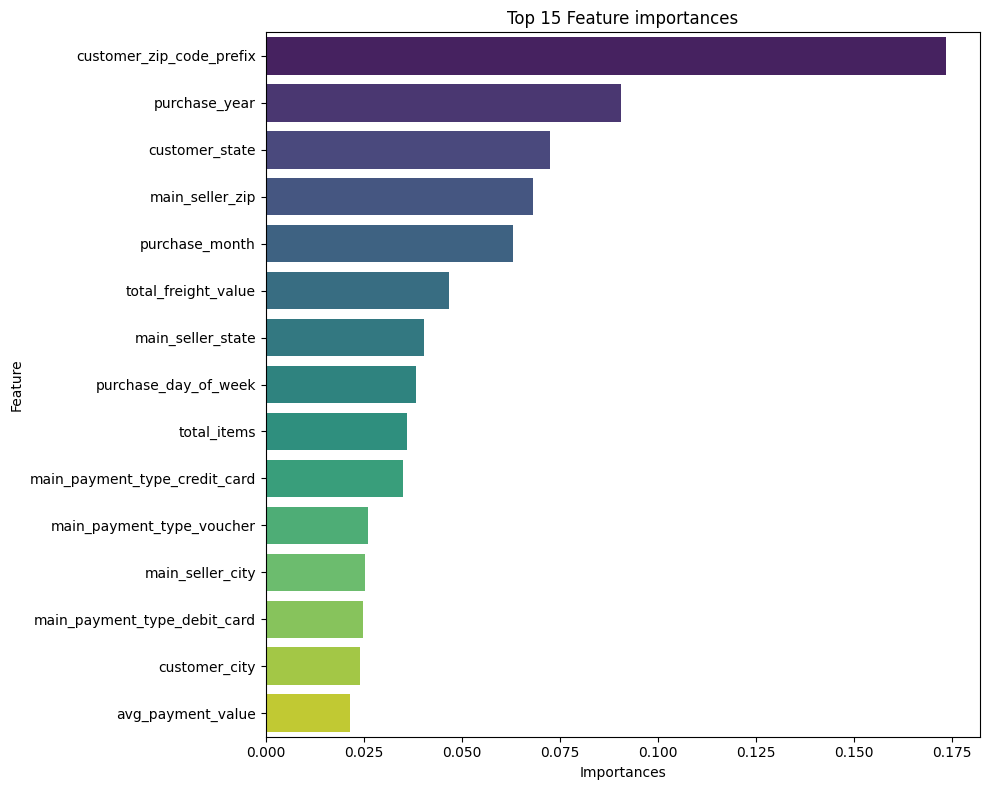

In [0]:
xgb_model = best_model.named_steps['model']

feature_names = []

# OHE columns (main_payment_type)
ohe_feature_names = best_model.named_steps['preprocessor'].named_transformers_['ohe'].named_steps['onehot'].get_feature_names_out(ohe_columns)
feature_names.extend(ohe_feature_names)

# Categorical column
feature_names.extend(cat_columns)

# Numerical columns
feature_names.extend(num_columns)

# Feature importances
importances = pd.DataFrame({
    'Feature': feature_names,
    'Importances': xgb_model.feature_importances_
})
importances = importances.sort_values(by='Importances', ascending=False)

# Top 15
top_15 = importances.head(15)


plt.figure(figsize=(10, 8))
sns.barplot(x='Importances', y='Feature', hue='Feature', data=top_15, palette='viridis', legend=False)
plt.title('Top 15 Feature importances')
plt.xlabel('Importances')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## SHAP explainer

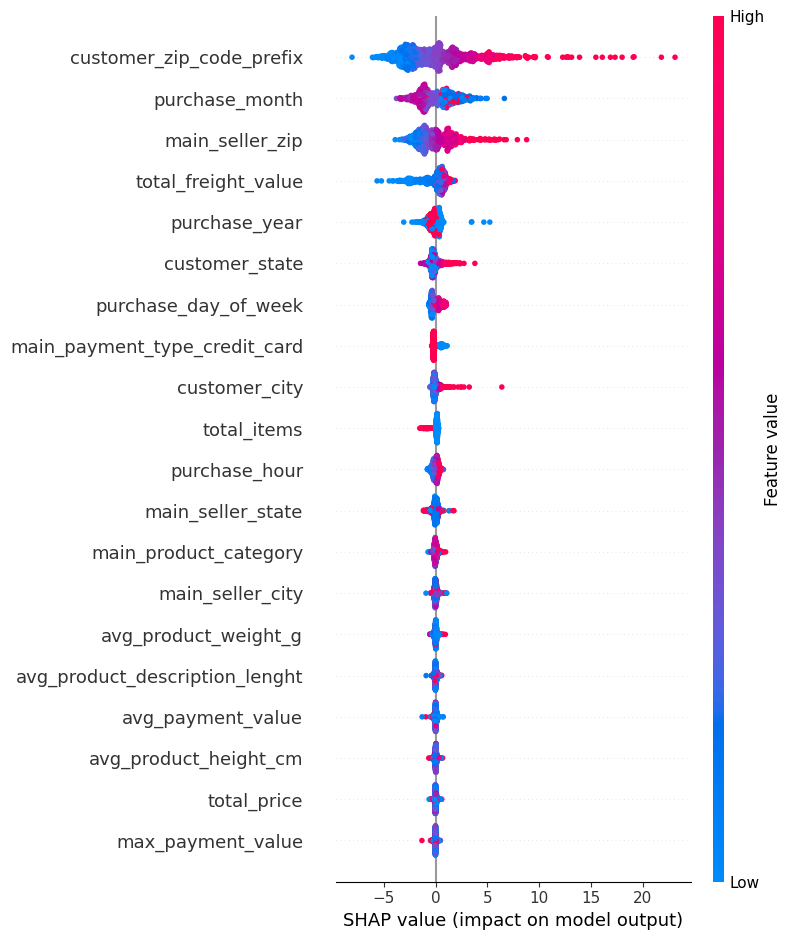

In [0]:
X_test_prep = best_model.named_steps['preprocessor'].transform(X_test)


dt_shap = shap.TreeExplainer(xgb_model)
shap_values = dt_shap.shap_values(X_test_prep[:1000])

shap.summary_plot(shap_values, X_test_prep[:1000], feature_names=feature_names, show=True)

Heres what we can conclude from the SHAP plot:
- An important feature for the model is the customers ZIP code; when its value is high, delivery times increase
- In earlier months, delivery times increase, while they decrease toward the end of the year
- The ZIP code is a factor in longer delivery times, but this is due to a correlation between the customers ZIP code and the area where they live
- Packages with low delivery costs are also delivered faster
 
The other values do not have as significant an impact on the models decisions 
